# Análisis Volumen, Características y Calidad de Prestamos

# Proposito del Notebook

- Responder preguntas relevantes del negocio, centrándose en el volumen, características y calidad de los prestamos.
- Graficar tendencias, distribuciones y comportamiento de los datos.

# Conexiones y librerias

In [1]:
from conexiones import obtener_engine
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator 
from sqlalchemy import text
import seaborn as sns 
engine = obtener_engine()

df_prestamos = pd.read_sql_query(
    text("""
        SELECT 
            oficial_llave,
            sucursal_llave,
            producto_llave,
            fecha_otorgamiento,
            plazo_meses,
            dias_mora,
            clasificacion_riesgo_sbs,
            monto_original,
            tasa_interes_efectiva_anual,
            canal_desembolso
        FROM oro.fact_prestamos"""),
    con= engine
)
df_prestamos_tra = df_prestamos.copy()

df_sucursales = pd.read_sql_query(
    text("""
        SELECT 
            sucursal_llave,
            nombre_sucursal
        FROM oro.dim_sucursales"""),
    con= engine
)
df_sucursales_tra = df_sucursales.copy()

df_oficiales = pd.read_sql_query(
    text("""
        SELECT 
            oficial_llave,
            nombres,
            apellido_paterno,
            apellido_materno 
        FROM oro.dim_oficiales_credito"""),
    con= engine
)
df_oficiales_tra = df_oficiales.copy()

df_productos = pd.read_sql_query(
    text("""
        SELECT 
            producto_llave,
            nombre_producto
        FROM oro.dim_productos_crediticios"""),
    con= engine
)
df_productos_tra = df_productos.copy()

In [2]:
df_prestamos_tra["fecha_otorgamiento"] = pd.to_datetime(df_prestamos_tra.fecha_otorgamiento)

In [3]:
df_prestamos_tra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6495 entries, 0 to 6494
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   oficial_llave                6495 non-null   int64         
 1   sucursal_llave               6495 non-null   int64         
 2   producto_llave               6495 non-null   int64         
 3   fecha_otorgamiento           6495 non-null   datetime64[ns]
 4   plazo_meses                  6495 non-null   int64         
 5   dias_mora                    6495 non-null   int64         
 6   clasificacion_riesgo_sbs     6495 non-null   object        
 7   monto_original               6495 non-null   float64       
 8   tasa_interes_efectiva_anual  6495 non-null   float64       
 9   canal_desembolso             6495 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(2)
memory usage: 507.5+ KB


In [4]:
# Para estandarizar todo a PEN, lo que voy a realizar es cambiar los creditos hipotecarios a soles 
tasa_cambio = 3.36
mascara_creditos_usd = df_prestamos_tra.producto_llave == 7
df_prestamos_tra.loc[mascara_creditos_usd,"monto_original"] = round(df_prestamos_tra.loc[mascara_creditos_usd,"monto_original"]*tasa_cambio,2)

In [5]:
sns.set_theme(style='whitegrid')

# Volumen de préstamos

## ¿Cuál es la tendencia anual de los préstamos otorgados?

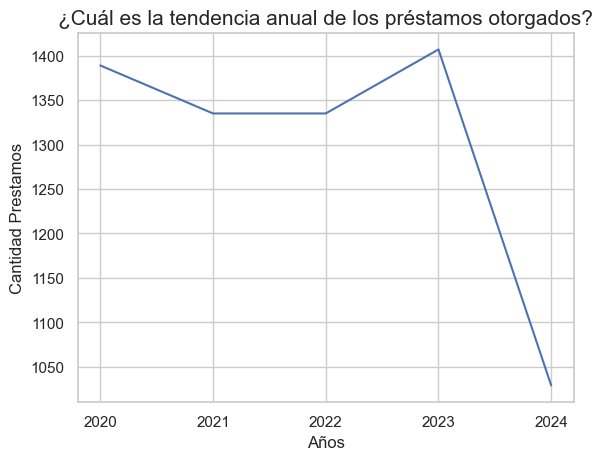

In [6]:
df_tendencia_prestamos = (
    df_prestamos_tra["fecha_otorgamiento"]
    .copy()
    .dt.year
    .value_counts()
    .reset_index()
    .sort_values(by='fecha_otorgamiento')
)

sns.lineplot(data=df_tendencia_prestamos,x='fecha_otorgamiento',y='count')
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel("Años")
plt.ylabel("Cantidad Prestamos")
plt.title("¿Cuál es la tendencia anual de los préstamos otorgados?",fontsize=15)
plt.show()

## ¿Cuál es la tendencia anual del total de montos prestados por año?

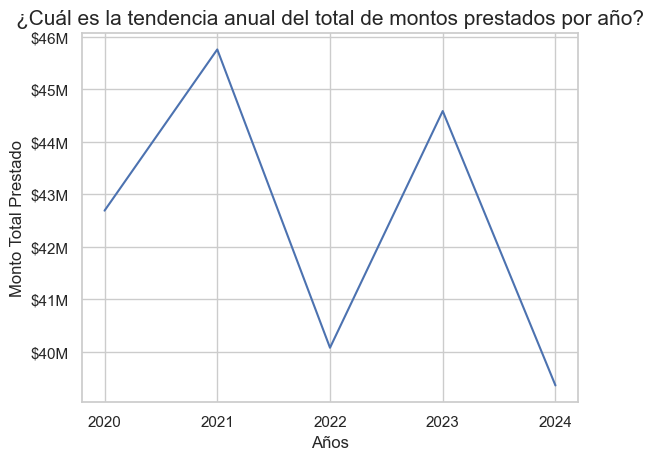

In [7]:
# Monto total por mes 
df_tendencia_montos = df_prestamos_tra[["fecha_otorgamiento","monto_original"]].copy()
df_tendencia_montos["anio"] = df_tendencia_montos.fecha_otorgamiento.dt.year
df_tendencia_montos_group = df_tendencia_montos.groupby('anio').agg(
    montos_totales = ('monto_original','sum')
).reset_index()

sns.lineplot(data=df_tendencia_montos_group,x='anio',y='montos_totales')
# Diseño
plt.xlabel("Años")
plt.ylabel("Monto Total Prestado")
plt.title("¿Cuál es la tendencia anual del total de montos prestados por año?",fontsize=15)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f"${round(x/1000000)}M"))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

## ¿Qué sucursales tienen mayor cantidad de préstamos?

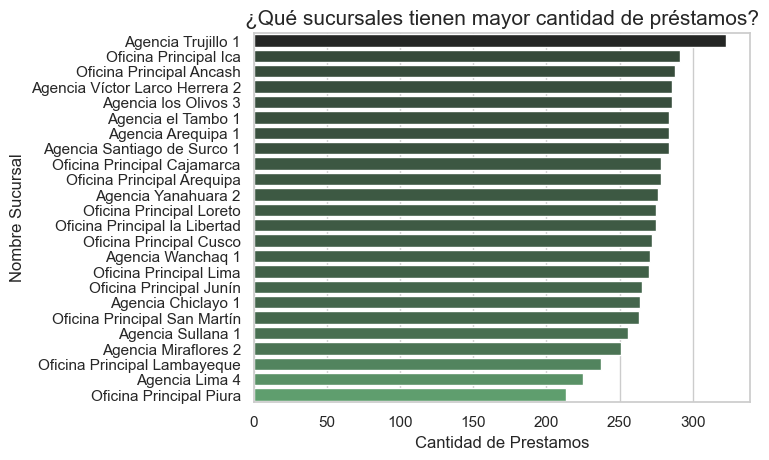

In [8]:
df_sucur_prestamos = df_prestamos_tra['sucursal_llave'].reset_index().merge(
    right = df_sucursales_tra,
    on='sucursal_llave'
)
df_sucur_prestamos_group = df_sucur_prestamos.nombre_sucursal.value_counts().reset_index().sort_values(by='count',ascending=False)

sns.barplot(data=df_sucur_prestamos_group,x='count',y='nombre_sucursal',hue='count',palette='dark:g_r',legend=False)
plt.title("¿Qué sucursales tienen mayor cantidad de préstamos?",fontsize=15)
plt.xlabel("Cantidad de Prestamos")
plt.ylabel("Nombre Sucursal")
plt.show()

## ¿Qué oficiales de crédito tienen mayor cantidad de préstamos?

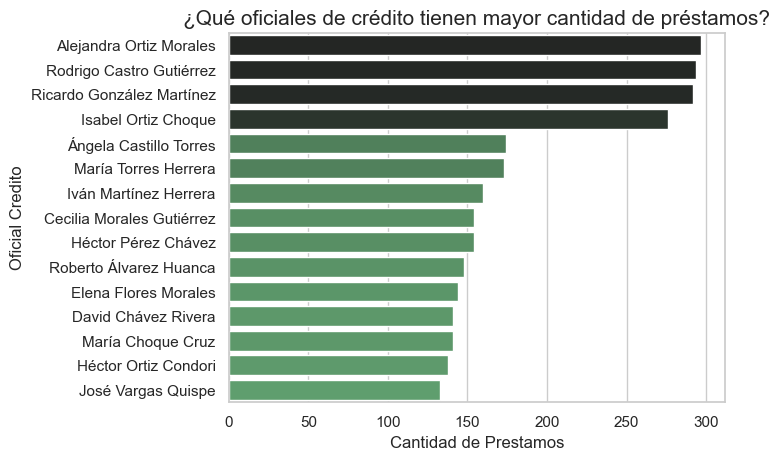

In [9]:
df_ofi_presta = df_prestamos_tra['oficial_llave'].reset_index().merge(
    right = df_oficiales_tra,
    on='oficial_llave'
)

df_ofi_presta["nombre_completo"] = df_ofi_presta.apply(
    axis= 1,
    func = lambda x: x['nombres'] + ' ' + x['apellido_paterno'] + ' ' + x['apellido_materno'] 
)
# Top 15 oficiales com mayor cantidad de prestamos
df_ofi_presta_group = (
    df_ofi_presta.nombre_completo
    .value_counts()
    .reset_index()
    .sort_values(by='count',ascending=False)
    .head(15)
)

sns.barplot(data=df_ofi_presta_group,x='count',y='nombre_completo',hue='count',palette='dark:g_r',legend=False)
plt.title("¿Qué oficiales de crédito tienen mayor cantidad de préstamos?",fontsize=15)
plt.xlabel("Cantidad de Prestamos")
plt.ylabel("Oficial Credito")
plt.show()

## ¿Qué productos crediticios tienen mayor cantidad de préstamos?

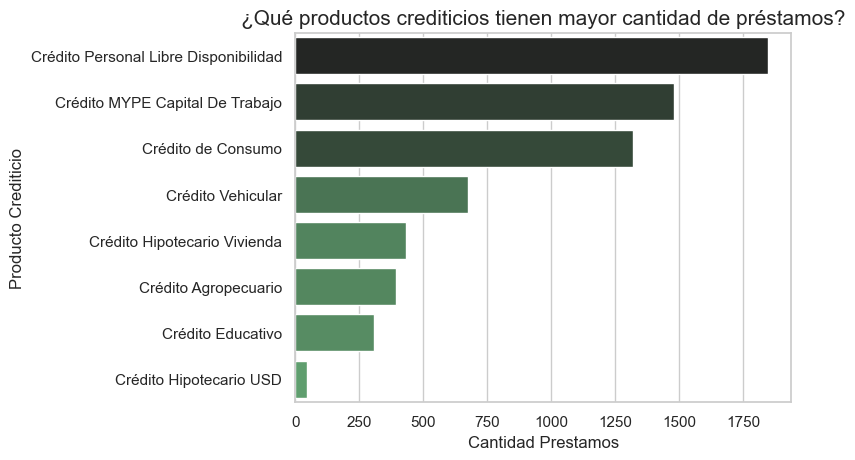

In [10]:
df_produc_pres = df_prestamos_tra['producto_llave'].reset_index().merge(
    right = df_productos_tra,
    on='producto_llave'
)
df_producto_pres_datos = df_produc_pres.nombre_producto.value_counts().reset_index()
sns.barplot(data=df_producto_pres_datos,y='nombre_producto',x='count',hue='count',palette='dark:g_r',legend=False)
plt.title("¿Qué productos crediticios tienen mayor cantidad de préstamos?",fontsize=15)
plt.xlabel("Cantidad Prestamos")
plt.ylabel("Producto Crediticio")
plt.show()

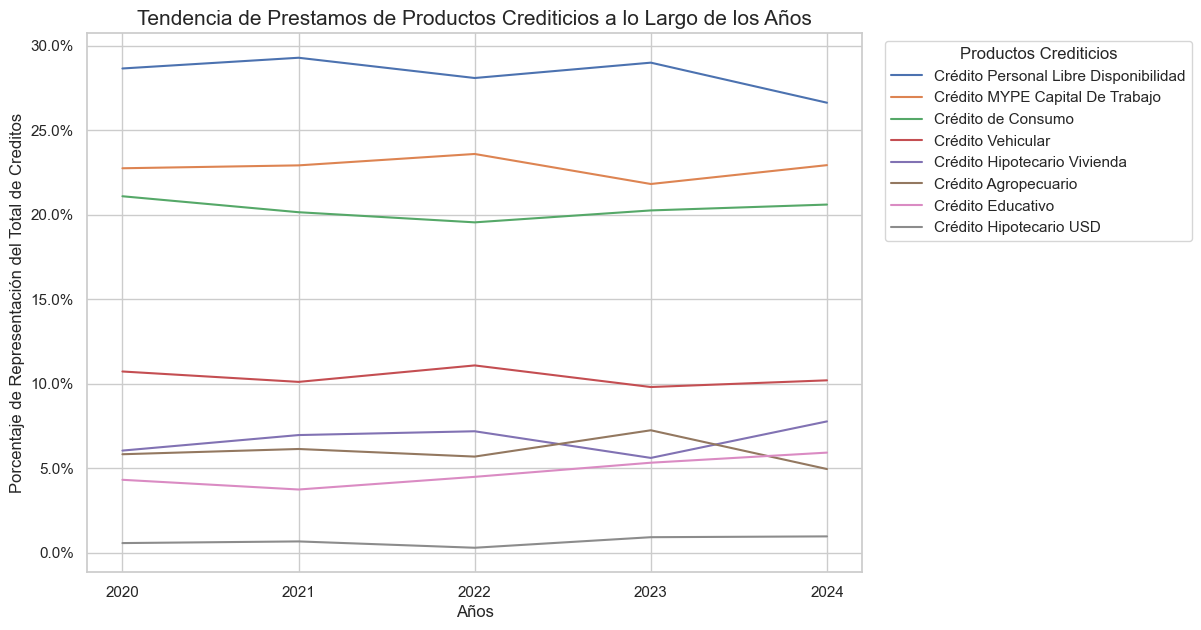

In [11]:
df_produc_pres_anio = df_prestamos_tra[['producto_llave','fecha_otorgamiento']].merge(
    right = df_productos_tra,
    on='producto_llave'
)

df_produc_pres_anio['anio'] = df_produc_pres_anio.fecha_otorgamiento.dt.year
total_por_anio = df_produc_pres_anio.anio.value_counts().sort_index()
# Cantidad de Prestamos por año para cada producto
df_produc_pres_anio_pivot = df_produc_pres_anio.pivot_table(index='anio',columns='nombre_producto',aggfunc='size')
# Ordena en funcion de la cantidad total de prestamos de cada producto a lo largo de los año 
df_produc_pres_anio_pivot.loc['total'] = df_produc_pres_anio_pivot.sum()
df_produc_pres_anio_pivot = df_produc_pres_anio_pivot[df_produc_pres_anio_pivot.loc['total'].sort_values(ascending=False).index]
# Elimina el indice total, para que no salga en el grafico de lineas 
df_produc_pres_anio_pivot.drop(index='total',inplace=True)

# /100, para que de porcentaje, tambien se podria multiplicar el resultado por 100
df_produc_pres_anio_grafico = df_produc_pres_anio_pivot.div(total_por_anio/100, axis = 0)

# Grafico y diseño 
plt.figure(figsize=(10,7))
sns.lineplot(data=df_produc_pres_anio_grafico,dashes=False)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f"{round(y,2)}%"))
plt.legend(title="Productos Crediticios", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("Tendencia de Prestamos de Productos Crediticios a lo Largo de los Años",fontsize=15)
plt.xlabel("Años")
plt.ylabel("Porcentaje de Representación del Total de Creditos")
plt.show()

## ¿Qué canales de desembolso son los más utilizados?

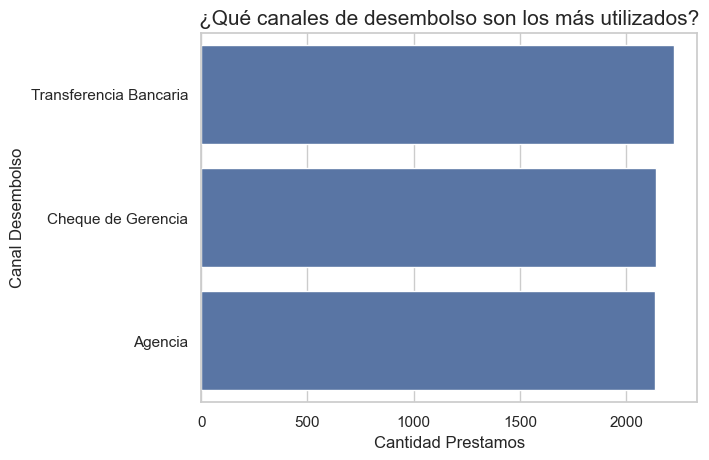

In [12]:
df_canal_desem = df_prestamos_tra.canal_desembolso.value_counts().reset_index().sort_values('canal_desembolso',ascending=False)
sns.barplot(data=df_canal_desem,y='canal_desembolso',x='count')
plt.title("¿Qué canales de desembolso son los más utilizados?",fontsize=15)
plt.xlabel("Cantidad Prestamos")
plt.ylabel("Canal Desembolso")
plt.show()

# Características de los préstamos

## ¿Cuál es la tendencia de la tasa efectiva anual?

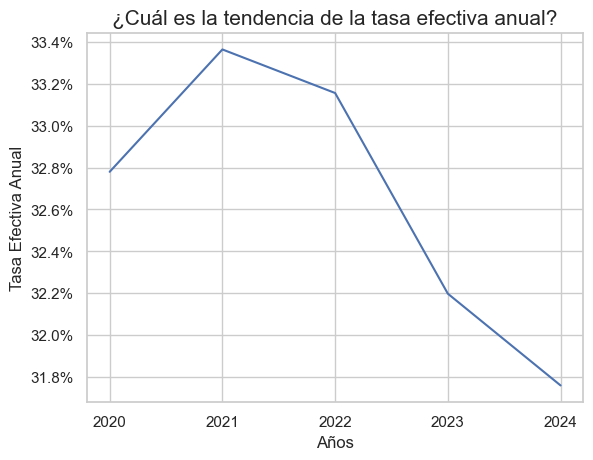

In [13]:
df_tendencia_tasa_efectiva = df_prestamos_tra[['fecha_otorgamiento','tasa_interes_efectiva_anual']].copy()
df_tendencia_tasa_efectiva['anio'] = df_tendencia_tasa_efectiva.fecha_otorgamiento.dt.year 
df_tendencia_tasa_efectiva_group = (
    df_tendencia_tasa_efectiva.groupby('anio')['tasa_interes_efectiva_anual']
    .median()
    .reset_index()
    .sort_values('anio')
)

sns.lineplot(data=df_tendencia_tasa_efectiva_group,x='anio',y='tasa_interes_efectiva_anual')
plt.title("¿Cuál es la tendencia de la tasa efectiva anual?",fontsize=15)
plt.xlabel("Años")
plt.ylabel("Tasa Efectiva Anual")
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"{round(y,2)}%"))
plt.show()

## ¿Cuál es la mediana del monto original y la tasa efectiva por producto?

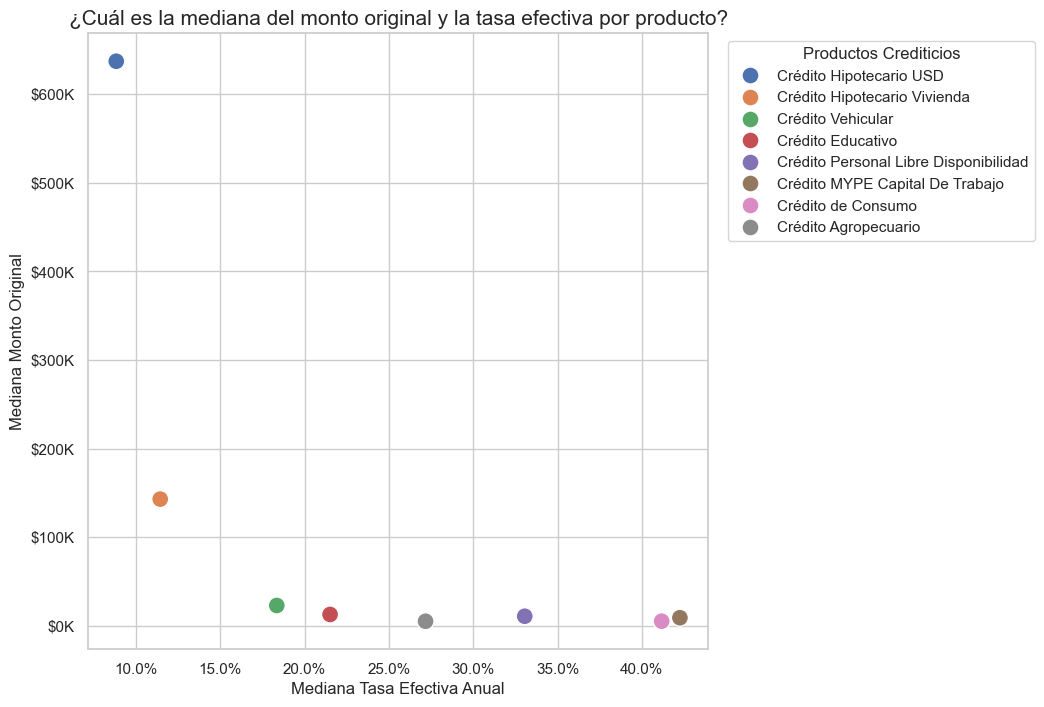

In [14]:
df_monto_origi_tasa_producto = df_prestamos_tra[['producto_llave','monto_original','tasa_interes_efectiva_anual']].merge(
    right=df_productos_tra,
    on='producto_llave'
)
df_grafico = df_monto_origi_tasa_producto.groupby('nombre_producto').agg(
    mediana_monto_original = ("monto_original","median"),
    mediana_tasa_efectiva_anual = ("tasa_interes_efectiva_anual",'median')
).sort_values(by="mediana_monto_original",ascending=False)

plt.figure(figsize=(8,8))
sns.scatterplot(
    data = df_grafico,
    y= 'mediana_monto_original',
    x= 'mediana_tasa_efectiva_anual',
    hue= df_grafico.index,
    s=150
)

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f"${round(x/1000)}K"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f"{round(x,2)}%"))
plt.legend(title="Productos Crediticios", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("¿Cuál es la mediana del monto original y la tasa efectiva por producto?",fontsize=15)
plt.xlabel("Mediana Tasa Efectiva Anual")
plt.ylabel("Mediana Monto Original")
plt.show()

## ¿Cuál es la mediana del plazo en meses por producto?

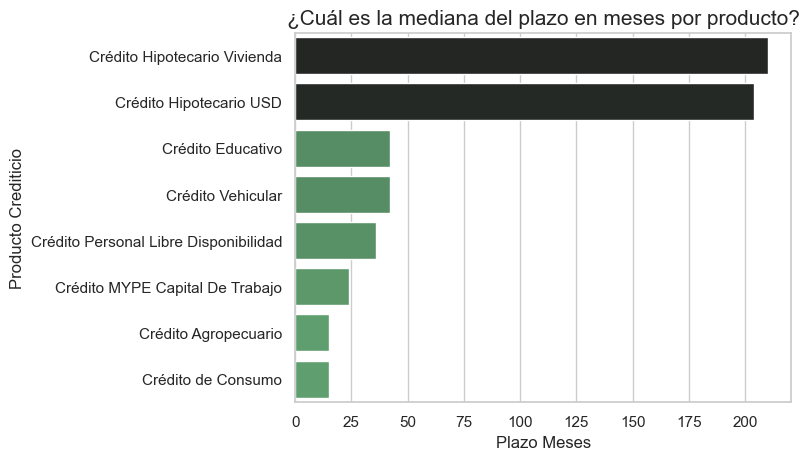

In [15]:
df_plazo_meses_pro =df_prestamos_tra[['producto_llave','plazo_meses']].merge(
    right= df_productos_tra,
    on='producto_llave'
)
df_plazo_meses_pro_group = (
    df_plazo_meses_pro
    .groupby('nombre_producto')['plazo_meses']
    .median()
    .reset_index()
    .sort_values(by="plazo_meses",ascending=False)
)

sns.barplot(
    data=df_plazo_meses_pro_group,
    x='plazo_meses',
    y='nombre_producto',
    hue='plazo_meses',
    palette='dark:g_r',
    legend=False
)
plt.title("¿Cuál es la mediana del plazo en meses por producto?",fontsize=15)
plt.xlabel("Plazo Meses")
plt.ylabel("Producto Crediticio")
plt.show()

# Calidad de los préstamos

## ¿Cuáles son las clasificaciones de riesgo SBS más comunes por cantidad de préstamos?

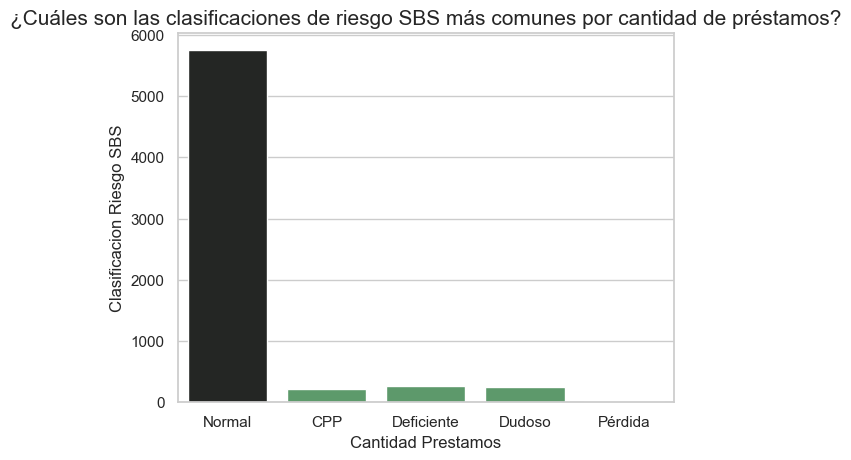

In [16]:
df_clasificacion_sbs = (
    df_prestamos_tra.clasificacion_riesgo_sbs
    .copy()
    .value_counts()
    .reset_index()
)
sns.barplot(
    data=df_clasificacion_sbs,
    x='clasificacion_riesgo_sbs',
    y='count',
    hue='count',
    palette='dark:g_r',
    legend=False,
    order=['Normal','CPP','Deficiente','Dudoso','Pérdida']
)
plt.title("¿Cuáles son las clasificaciones de riesgo SBS más comunes por cantidad de préstamos?",fontsize=15)
plt.ylabel("Clasificacion Riesgo SBS")
plt.xlabel("Cantidad Prestamos")
plt.show()

## ¿Qué monto prestado representa cada clasificación de riesgo SBS?

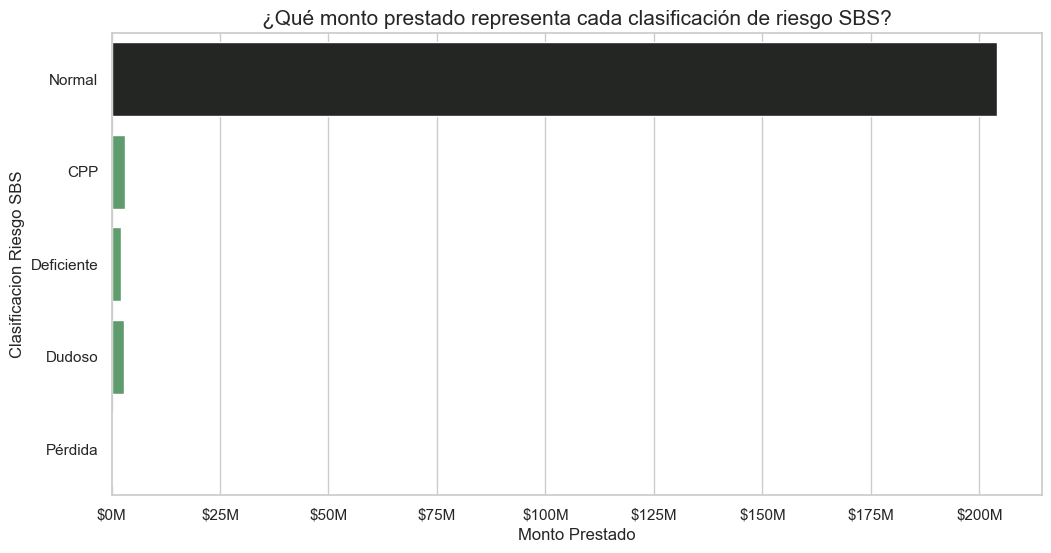

In [17]:
df_montos_sbs = df_prestamos_tra[["clasificacion_riesgo_sbs","monto_original"]].copy()
df_montos_sbs = df_prestamos_tra.groupby("clasificacion_riesgo_sbs")["monto_original"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(
    data= df_montos_sbs,
    y = "clasificacion_riesgo_sbs",
    x = "monto_original",
    hue = "monto_original",
    order=['Normal','CPP','Deficiente','Dudoso','Pérdida'],
    palette= "dark:g_r", 
    legend=False
)
plt.title("¿Qué monto prestado representa cada clasificación de riesgo SBS?", fontsize = 15)
plt.ylabel("Clasificacion Riesgo SBS")
plt.xlabel("Monto Prestado")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${round(x/1000000)}M"))
plt.show()

## ¿Qué rangos de días de mora son los más populares por producto?

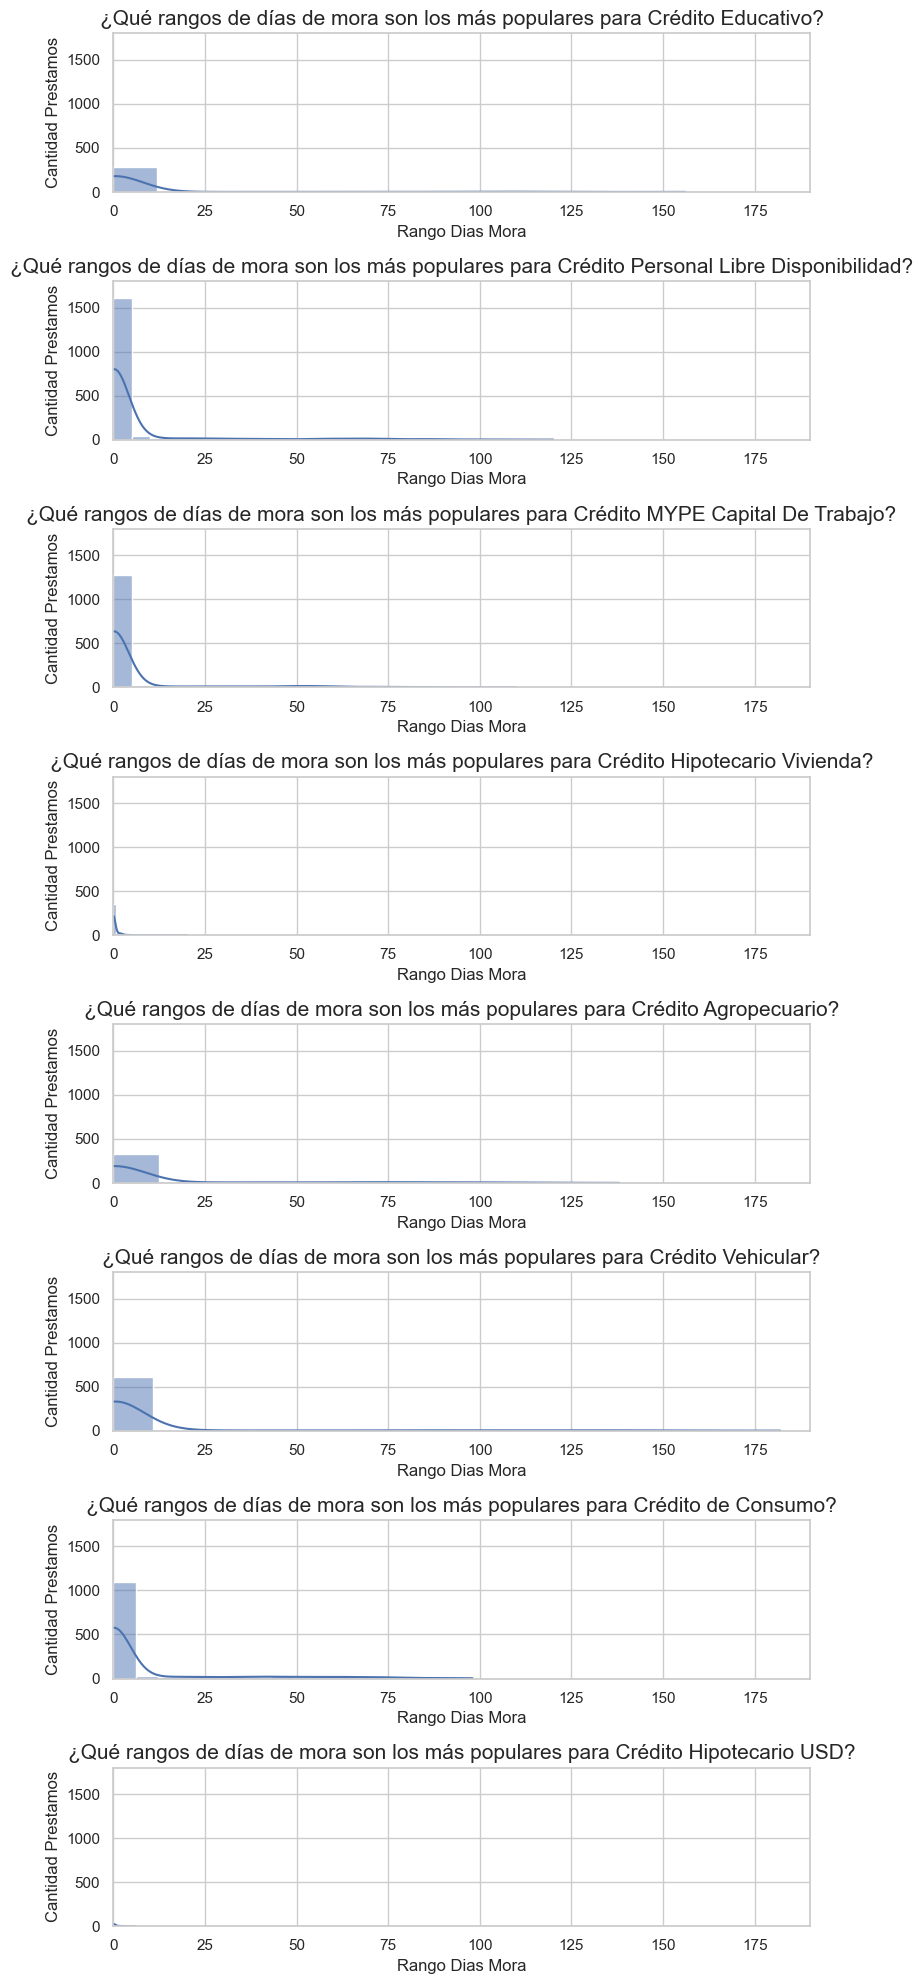

In [18]:
df_rango_mora_product = df_prestamos_tra[["producto_llave","dias_mora"]].merge(
    right= df_productos_tra,
    on='producto_llave'
)

nombre_productos = list(df_rango_mora_product.nombre_producto.unique())
cantidad_productos = len(nombre_productos)
fig, ax = plt.subplots(nrows=cantidad_productos, ncols= 1, figsize=(8,20))

for i in range(cantidad_productos):
    df_grafico_rango_mora = df_rango_mora_product.dias_mora[df_rango_mora_product.nombre_producto == nombre_productos[i]]
    
    sns.histplot(
        data= df_grafico_rango_mora,
        bins = 'scott',
        ax=ax[i],
        kde = True
    )
    ax[i].set_title(f"¿Qué rangos de días de mora son los más populares para {nombre_productos[i]}?", fontsize=15)
    ax[i].set_xlabel("Rango Dias Mora")
    ax[i].set_ylabel("Cantidad Prestamos")
    ax[i].set_xlim(0,190)
    ax[i].set_ylim(0,1800)
fig.tight_layout()